# Variational Fast-Forwarding (VFF) for Quantum Simulation

**Paper:** Cîrstoiu et al., *Variational fast forwarding for quantum simulation beyond the coherence time*, npj Quantum Information (2020). [arXiv:1910.04292](https://arxiv.org/abs/1910.04292)

This notebook implements VFF from scratch and demonstrates its key advantage:
**fixed-depth circuits that outperform Trotterization at long simulation times.**

## 1. Background

Simulating a quantum system under Hamiltonian $H$ for time $T$ requires the unitary $e^{-iHT}$.
Three strategies, with very different scaling:

| Strategy | Circuit depth | Fidelity at large $T$ |
|----------|--------------|----------------------|
| **Exact** | $e^{O(T)}$ gates | 1.0 (reference only) |
| **Trotterization** | $\propto N = T/\Delta t$ | Decays — noise accumulates each step |
| **VFF** | **Fixed** (independent of $N$) | Stays high — noise doesn't accumulate |

### How VFF works

**Phase 1 — Build $U(\Delta t)$:** Trotterize $e^{-iH\Delta t}$ into a short circuit.

**Phase 2 — Variational diagonalization (training):** Find $W(\boldsymbol{\theta})$ and $D(\boldsymbol{\gamma}, \Delta t)$ such that:
$$V(\boldsymbol{\alpha}, \Delta t) = W(\boldsymbol{\theta})\, D(\boldsymbol{\gamma}, \Delta t)\, W^\dagger(\boldsymbol{\theta}) \approx U(\Delta t)$$

**Phase 3 — Fast-forward:** For any time $T = N \Delta t$, *scale the diagonal only*:
$$e^{-iHT} \approx W(\boldsymbol{\theta})\, D(N\boldsymbol{\gamma}, \Delta t)\, W^\dagger(\boldsymbol{\theta}) \quad \leftarrow \text{fixed depth!}$$

In [1]:
import os, pickle, itertools, warnings
warnings.filterwarnings('ignore')

import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.optimize import minimize

from qiskit import transpile
from qiskit.quantum_info import SparsePauliOp, Operator, Statevector, DensityMatrix, state_fidelity
from qiskit.circuit import QuantumCircuit, ParameterVector, Parameter
from qiskit.circuit.library import EfficientSU2
from qiskit.circuit.library import PauliEvolutionGate
from qiskit.synthesis import SuzukiTrotter
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error


## 2. Configuration

Edit the cell below before running. Use `USE_PRETRAINED = True` to skip training
and load the saved parameters instantly. Switch it to `False` — or change any
model/Hamiltonian variable — to retrain from scratch.

| Variable | Options | Effect |
|----------|---------|--------|
| `MODEL` | `"TFIM"` · `"XY"` · `"Heisenberg"` | Which spin model to simulate |
| `N_QUBITS` | `2` · `4` | System size (4 = default, 2 = faster) |
| `J`, `h` | floats | TFIM coupling / transverse field |
| `Jx Jy Jz` | floats | Heisenberg couplings |
| `DELTA_T` | float > 0 | Trotter time step |
| `N_MAX` | int | Max timesteps for comparison plot |
| `NOISE_P` | 0 – 0.05 | Depolarizing error per 2-qubit gate |
| `W_REPS` | 1 · 2 | Ansatz depth for $W(\boldsymbol{\theta})$ |
| `USE_PRETRAINED` | `True` · `False` | Load saved params or retrain |

In [2]:
# ── HAMILTONIAN ──────────────────────────────────────────────────────────────
MODEL    = "TFIM"       # "TFIM" | "XY" | "Heisenberg"
N_QUBITS = 4            # 4 (default) — change to 2 for faster runs

# Model-specific couplings (used when USE_PRETRAINED=False or custom model)
J, h             = 1.0, 0.5    # TFIM: ZZ coupling, transverse field
Jx, Jy, Jz      = 1.0, 1.0, 1.0  # XY / Heisenberg couplings

# ── SIMULATION ────────────────────────────────────────────────────────────────
DELTA_T          = 0.2          # time step (a.u.)
N_MAX            = 30           # max timesteps for the comparison plot
NOISE_P          = 0.02         # depolarising error rate per 2-qubit gate

# ── VFF ANSATZ ────────────────────────────────────────────────────────────────
W_REPS           = 1            # EfficientSU2 repetitions for W(θ)
D_ORDER          = 2            # diagonal order: 1 = Rz only, 2 = Rz + RZZ

# ── WORKFLOW ──────────────────────────────────────────────────────────────────
USE_PRETRAINED   = True         # True = load saved params; False = retrain
SEED             = 42

# ─────────────────────────────────────────────────────────────────────────────
PRETRAINED_MODELS = {"TFIM": 1, "XY": 2, "Heisenberg": 2}   # model → W_REPS
print(f"Model: {MODEL}  |  Qubits: {N_QUBITS}  |  Δt: {DELTA_T}  |  Noise: {NOISE_P}")
print(f"N_MAX: {N_MAX}  |  W_REPS: {W_REPS}  |  USE_PRETRAINED: {USE_PRETRAINED}")


Model: TFIM  |  Qubits: 4  |  Δt: 0.2  |  Noise: 0.02
N_MAX: 30  |  W_REPS: 1  |  USE_PRETRAINED: True


## 3. Hamiltonian

Pre-saved Hamiltonians (`.pkl` files in `hamiltonians/`) are loaded for the
three built-in models. If you change `J`, `h`, or qubit count, the Hamiltonian
is rebuilt inline — no restart needed.

In [3]:
def build_hamiltonian(model, n, J=1.0, h=0.5, Jx=1.0, Jy=1.0, Jz=1.0):
    """Construct SparsePauliOp for the chosen model."""
    def pp(op, i, n): return 'I'*(n-len(op)-i) + op + 'I'*i
    terms = []
    if model == 'TFIM':
        terms  = [(pp('ZZ', i, n), -J) for i in range(n-1)]
        terms += [(pp('X',  i, n), -h) for i in range(n)]
    elif model == 'XY':
        terms  = [(pp('XX', i, n), -Jx) for i in range(n-1)]
        terms += [(pp('YY', i, n), -Jy) for i in range(n-1)]
    elif model == 'Heisenberg':
        terms  = [(pp('XX', i, n), -Jx) for i in range(n-1)]
        terms += [(pp('YY', i, n), -Jy) for i in range(n-1)]
        terms += [(pp('ZZ', i, n), -Jz) for i in range(n-1)]
    else:
        raise ValueError(f'Unknown model: {model}')
    return SparsePauliOp.from_list(terms)


pkl_path = f'hamiltonians/{MODEL.lower()}_{N_QUBITS}q.pkl'
if USE_PRETRAINED and os.path.exists(pkl_path) and N_QUBITS == 4:
    with open(pkl_path, 'rb') as f:
        H = pickle.load(f)
    print(f'Loaded {pkl_path}')
else:
    H = build_hamiltonian(MODEL, N_QUBITS, J=J, h=h, Jx=Jx, Jy=Jy, Jz=Jz)
    print(f'Built {MODEL} Hamiltonian inline')

H_mat = H.to_matrix()
eigvals = np.linalg.eigvalsh(H_mat)
print(f'Qubits: {H.num_qubits}  |  Terms: {len(H)}  |  '
      f'Eigenvalues: [{eigvals.min():.3f}, ..., {eigvals.max():.3f}]')

Loaded hamiltonians/tfim_4q.pkl
Qubits: 4  |  Terms: 7  |  Eigenvalues: [-3.427, ..., 3.427]


## 4. Circuit Diagrams

Four separate diagrams — one per component of the VFF algorithm.

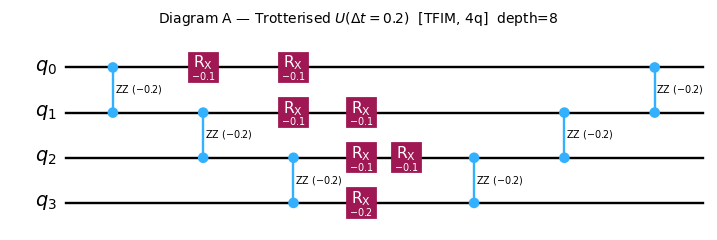

In [4]:
# ── Diagram A: Trotterised U(Δt) ─────────────────────────────────────────────
trotter = SuzukiTrotter(order=2, reps=1)
evo_gate = PauliEvolutionGate(H, time=DELTA_T, synthesis=trotter)
qc_trotter = QuantumCircuit(N_QUBITS)
qc_trotter.append(evo_gate, range(N_QUBITS))
qc_trotter = qc_trotter.decompose()

fig, ax = plt.subplots(figsize=(12, 2.5))
qc_trotter.draw('mpl', style='iqp', fold=70, ax=ax)
ax.set_title(f'Diagram A — Trotterised $U(\\Delta t={DELTA_T})$  '
             f'[{MODEL}, {N_QUBITS}q]  depth={qc_trotter.depth()}', fontsize=10)
plt.tight_layout(); plt.show()

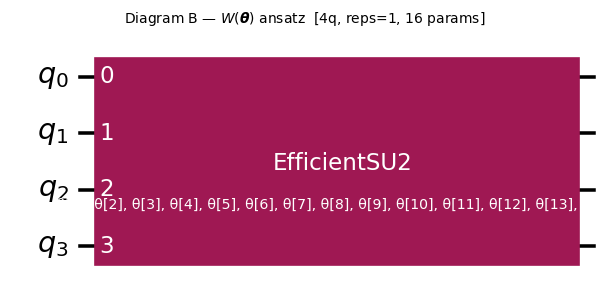

In [5]:
# ── Diagram B: W(θ) eigenvector ansatz ───────────────────────────────────────
W = EfficientSU2(N_QUBITS, reps=W_REPS, entanglement='linear', parameter_prefix='θ')

fig, ax = plt.subplots(figsize=(12, 3))
W.draw('mpl', style='iqp', fold=70, ax=ax)
ax.set_title(f'Diagram B — $W(\\boldsymbol{{\\theta}})$ ansatz  '
             f'[{N_QUBITS}q, reps={W_REPS}, {W.num_parameters} params]', fontsize=10)
plt.tight_layout(); plt.show()

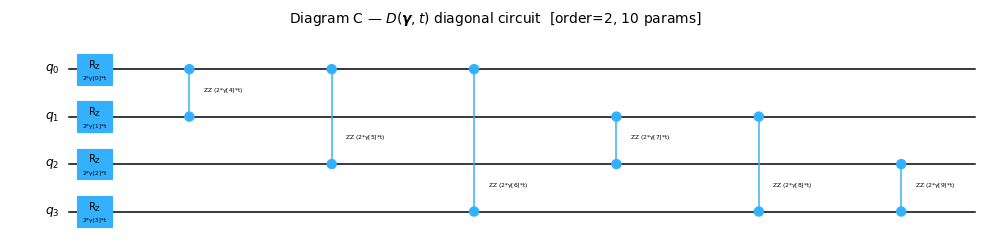

In [6]:
# ── Diagram C: D(γ, t) diagonal ansatz ──────────────────────────────────────
_t     = Parameter('t')
_pairs = list(itertools.combinations(range(N_QUBITS), 2)) if D_ORDER >= 2 else []
_gamma = ParameterVector('γ', N_QUBITS + len(_pairs))
qc_D   = QuantumCircuit(N_QUBITS, name='D(γ,t)')
for k in range(N_QUBITS):
    qc_D.rz(2 * _gamma[k] * _t, k)
for idx, (a, b) in enumerate(_pairs):
    qc_D.rzz(2 * _gamma[N_QUBITS + idx] * _t, a, b)

fig, ax = plt.subplots(figsize=(10, 2.5))
qc_D.draw('mpl', style='iqp', fold=70, ax=ax)
ax.set_title(f'Diagram C — $D(\\boldsymbol{{\\gamma}}, t)$ diagonal circuit  '
             f'[order={D_ORDER}, {len(_gamma)} params]', fontsize=10)
plt.tight_layout(); plt.show()

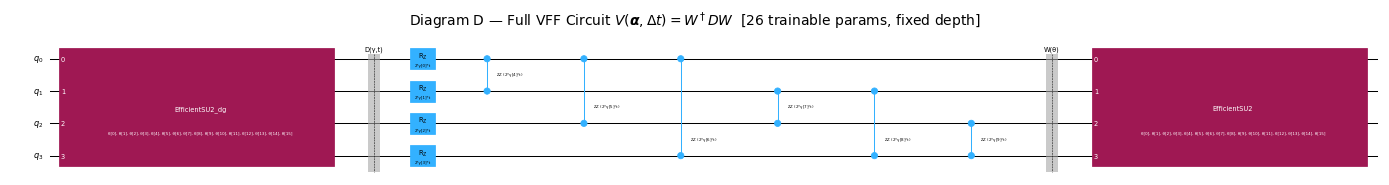

In [7]:
# ── Diagram D: Full VFF circuit V = W† D W ───────────────────────────────────
qc_vff_diag = QuantumCircuit(N_QUBITS, name='V = W†DW')
qc_vff_diag.compose(W.inverse(), inplace=True)
qc_vff_diag.barrier(label='D(γ,t)')
qc_vff_diag.compose(qc_D, inplace=True)
qc_vff_diag.barrier(label='W(θ)')
qc_vff_diag.compose(W, inplace=True)

fig, ax = plt.subplots(figsize=(14, max(3, N_QUBITS)))
qc_vff_diag.draw('mpl', style='iqp', fold=90, ax=ax)
ax.set_title(f'Diagram D — Full VFF Circuit $V(\\boldsymbol{{\\alpha}},\\Delta t) = W^\\dagger D W$  '
             f'[{W.num_parameters + len(_gamma)} trainable params, fixed depth]', fontsize=10)
plt.tight_layout(); plt.show()

## 5. VFF Training

We minimise the **Hilbert-Schmidt cost** between the Trotterised $U(\Delta t)$ and the VFF
ansatz $V(\boldsymbol{\alpha}, \Delta t)$:

$$C_{\mathrm{HST}}(U, V) = 1 - \frac{|\mathrm{Tr}(U^\dagger V)|^2}{d^2}$$

For $d = 2^4 = 16$ this is just a 16×16 matrix inner product — very fast to evaluate.

With `USE_PRETRAINED = True` the optimised parameters are loaded instantly.
Set it to `False` (or change model/Δt) to retrain.

In [8]:
def build_vff_circuit(n, w_reps=1, d_order=2):
    """Return (full_circuit, w_params, gamma_params, t_param)."""
    t      = Parameter('t')
    pairs  = list(itertools.combinations(range(n), 2)) if d_order >= 2 else []
    gamma  = ParameterVector('γ', n + len(pairs))
    w      = EfficientSU2(n, reps=w_reps, entanglement='linear', parameter_prefix='θ')
    d_circ = QuantumCircuit(n, name='D')
    for k in range(n):
        d_circ.rz(2 * gamma[k] * t, k)
    for idx, (a, b) in enumerate(pairs):
        d_circ.rzz(2 * gamma[n + idx] * t, a, b)
    qc = QuantumCircuit(n, name='VFF')
    qc.compose(w.inverse(), inplace=True)
    qc.barrier()
    qc.compose(d_circ, inplace=True)
    qc.barrier()
    qc.compose(w, inplace=True)
    return qc, list(w.parameters), list(gamma), t


def hs_cost(params, qc, w_params, g_params, t_param, u_mat, dt, history=None):
    n_w = len(w_params)
    pd  = {p: params[i]           for i, p in enumerate(w_params)}
    pd.update({p: params[n_w + i] for i, p in enumerate(g_params)})
    pd[t_param] = dt
    v   = Operator(qc.assign_parameters(pd)).data
    c   = 1.0 - abs(np.trace(u_mat.conj().T @ v))**2 / u_mat.shape[0]**2
    if history is not None:
        history.append(float(c))
    return c

In [9]:
qc_vff, w_params, g_params, t_param = build_vff_circuit(N_QUBITS, W_REPS, D_ORDER)
n_params = len(w_params) + len(g_params)
u_mat    = expm(-1j * H_mat * DELTA_T)

param_file = (f'trained_params/vff_{MODEL.lower()}_{N_QUBITS}q_dt{DELTA_T}.npz')
_reps_match = PRETRAINED_MODELS.get(MODEL) == W_REPS

if USE_PRETRAINED and os.path.exists(param_file) and N_QUBITS == 4 and _reps_match:
    data      = np.load(param_file, allow_pickle=True)
    theta_opt = data['theta']
    gamma_opt = data['gamma']
    history   = list(data['history'])
    print(f'Loaded pre-trained params from {param_file}')
    print(f'Pre-trained cost: {history[-1]:.5f}')
else:
    print('Training VFF — this takes ~1-3 min for 4 qubits ...')
    np.random.seed(SEED)
    x0      = np.random.uniform(-np.pi, np.pi, n_params)
    history = []
    result  = minimize(
        hs_cost, x0,
        args=(qc_vff, w_params, g_params, t_param, u_mat, DELTA_T, history),
        method='COBYLA',
        options={'maxiter': 1500, 'rhobeg': 0.5},
    )
    theta_opt = result.x[:len(w_params)]
    gamma_opt = result.x[len(w_params):]
    print(f'Final cost: {history[-1]:.5f}  '
          f'({"converged" if result.success else "reached max iter"})')

all_params_opt = np.concatenate([theta_opt, gamma_opt])

Loaded pre-trained params from trained_params/vff_tfim_4q_dt0.2.npz
Pre-trained cost: 0.02896


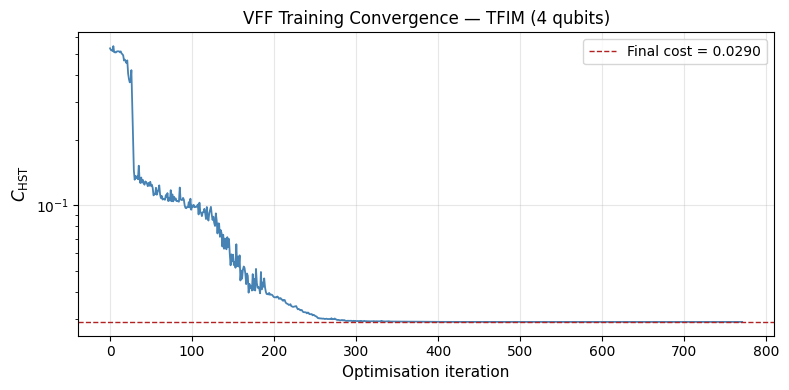

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(history, color='steelblue', linewidth=1.3)
ax.set_xlabel('Optimisation iteration', fontsize=11)
ax.set_ylabel('$C_{\\mathrm{HST}}$', fontsize=12)
ax.set_title(f'VFF Training Convergence — {MODEL} ({N_QUBITS} qubits)', fontsize=12)
ax.axhline(history[-1], color='firebrick', linestyle='--', linewidth=1,
           label=f'Final cost = {history[-1]:.4f}')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 6. Fidelity Comparison: VFF vs Trotterization

We now compare three approaches for simulating the state $e^{-iHT}|\psi_0\rangle$
at $T = N \cdot \Delta t$ for increasing $N$:

| Method | Circuit depth | Noise | Notes |
|--------|--------------|-------|-------|
| **Exact** | — | None | Reference ($F = 1$) |
| **Trotterization (noisy)** | $\propto N$ | Grows with $N$ | Fidelity decays |
| **VFF — ideal** | **Fixed** | None | Upper bound on VFF; only approximation error |

**Key observation:** Trotterization accumulates hardware noise with each additional
step — every gate has a depolarising error $p = $ `NOISE_P`. VFF uses a *fixed-depth*
circuit regardless of $N$, so hardware noise stays constant while only the rotation
angles $\gamma \times N$ scale.

The **fast-forwarding factor** $R_{\text{FF}}$ is the ratio of the total simulation
time to the single training time step — a measure of how much VFF extends the
coherence-limited simulation horizon.


In [11]:
# ── Noise model & simulator (density_matrix = correct average fidelity) ───────
from qiskit.quantum_info import DensityMatrix
noise_model = NoiseModel()
# Depolarising error on all 2-qubit gate types used by Qiskit / Aer
noise_model.add_all_qubit_quantum_error(
    depolarizing_error(NOISE_P, 2), ['cx', 'rzz', 'ecr', 'cz'])
noise_model.add_all_qubit_quantum_error(
    depolarizing_error(NOISE_P / 10, 1), ['rz', 'ry', 'rx', 'u'])
# density_matrix method correctly tracks the mixed state under stochastic noise
sim_noisy = AerSimulator(method='density_matrix', noise_model=noise_model)

# Initial state |+⟩^n  (equal superposition over all basis states)
psi0 = Statevector.from_label('+' * N_QUBITS)

# ── Helpers ───────────────────────────────────────────────────────────────────
def exact_state(N):
    """Exact state at time N·Δt via matrix exponential."""
    return Statevector(expm(-1j * H_mat * N * DELTA_T) @ psi0.data)

def trotter_fidelity_noisy(N):
    """
    Apply the Trotterised U(Δt) gate N times through the noisy AerSimulator.
    Circuit depth grows as N → noise accumulates with every step.
    Uses H-gate preparation of |+⟩ (no 'initialize' needed).
    """
    qc = QuantumCircuit(N_QUBITS)
    qc.h(range(N_QUBITS))          # prepare |+⟩^n from |0⟩^n
    for _ in range(N):
        qc.compose(qc_trotter, inplace=True)
    qc.save_density_matrix()
    qc_t = transpile(qc, sim_noisy)
    dm = DensityMatrix(sim_noisy.run(qc_t).result().data()['density_matrix'])
    return float(state_fidelity(dm, exact_state(N), validate=False))

def vff_fidelity_ideal(N):
    """
    VFF ideal (noiseless): W†·D(N·γ,Δt)·W evaluated as a pure-state unitary.
    Circuit depth is FIXED regardless of N — only the rotation angles scale.
    This is the upper bound on VFF performance (no hardware noise).
    """
    pd = {p: theta_opt[i]           for i, p in enumerate(w_params)}
    pd.update({p: gamma_opt[i] * N  for i, p in enumerate(g_params)})
    pd[t_param] = DELTA_T
    psi_vff = psi0.evolve(qc_vff.assign_parameters(pd))
    return float(state_fidelity(psi_vff, exact_state(N), validate=False))


In [12]:
print(f'Running comparison for N = 1 … {N_MAX} timesteps ...')
print(f'  (Trotter: density-matrix noisy sim  |  VFF: ideal noiseless)')
N_values         = list(range(1, N_MAX + 1))
fid_trotter_vals = []
fid_vff_vals     = []

for N in N_values:
    fid_trotter_vals.append(trotter_fidelity_noisy(N))
    fid_vff_vals.append(vff_fidelity_ideal(N))
    if N % 5 == 0:
        print(f'  N={N:3d}  Trotter(noisy)={fid_trotter_vals[-1]:.3f}  '
              f'VFF(ideal)={fid_vff_vals[-1]:.3f}')

print('Done.')


Running comparison for N = 1 … 30 timesteps ...
  (Trotter: density-matrix noisy sim  |  VFF: ideal noiseless)


  N=  5  Trotter(noisy)=0.626  VFF(ideal)=0.640
  N= 10  Trotter(noisy)=0.403  VFF(ideal)=0.493
  N= 15  Trotter(noisy)=0.266  VFF(ideal)=0.587
  N= 20  Trotter(noisy)=0.188  VFF(ideal)=0.399


  N= 25  Trotter(noisy)=0.138  VFF(ideal)=0.258
  N= 30  Trotter(noisy)=0.108  VFF(ideal)=0.189
Done.


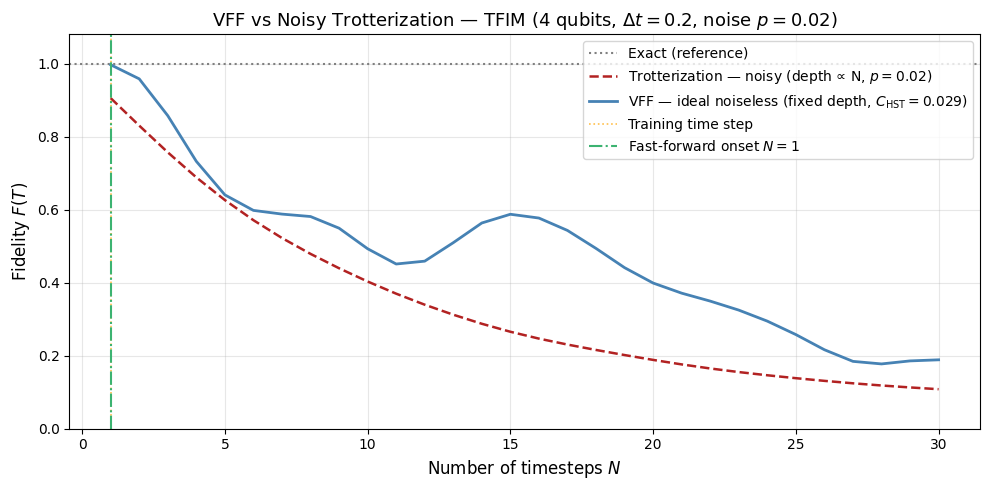

VFF outperforms noisy Trotterization from N = 1 onwards.
Fast-forwarding factor R_FF ≈ 30.0× (simulation time range / training time step)


In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.axhline(1.0, color='gray', linestyle=':', linewidth=1.5, label='Exact (reference)')
ax.plot(N_values, fid_trotter_vals, '--', color='firebrick', linewidth=1.8,
        label=f'Trotterization — noisy (depth ∝ N, $p={NOISE_P}$)')
ax.plot(N_values, fid_vff_vals, '-', color='steelblue', linewidth=2.0,
        label=f'VFF — ideal noiseless (fixed depth, '
              f'$C_{{\mathrm{{HST}}}}={history[-1]:.3f}$)')

# Mark the training boundary (the N used during training = 1)
ax.axvline(1, color='orange', linestyle=':', linewidth=1.2, alpha=0.7,
           label='Training time step')

# Fast-forwarding crossover: first N where VFF > Trotter
crossover = next((N_values[i] for i in range(len(N_values))
                  if fid_vff_vals[i] > fid_trotter_vals[i]), None)
if crossover:
    ax.axvline(crossover, color='mediumseagreen', linestyle='-.', linewidth=1.5,
               label=f'Fast-forward onset $N={crossover}$')

ax.set_xlabel('Number of timesteps $N$', fontsize=12)
ax.set_ylabel('Fidelity $F(T)$', fontsize=12)
ax.set_title(
    f'VFF vs Noisy Trotterization — {MODEL} ({N_QUBITS} qubits, '
    f'$\\Delta t={DELTA_T}$, noise $p={NOISE_P}$)',
    fontsize=13,
)
ax.set_ylim(0, 1.08)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

if crossover:
    print(f'VFF outperforms noisy Trotterization from N = {crossover} onwards.')
    print(f'Fast-forwarding factor R_FF ≈ {N_MAX / crossover:.1f}× '
          f'(simulation time range / training time step)')
else:
    print('Increase NOISE_P or N_MAX to see the VFF fast-forward advantage.')


---

## 5. Application: VFF for the H₂ Molecule

The sections above demonstrated VFF on a spin model you can build by hand.
Here we apply exactly the same pipeline to a **real chemistry Hamiltonian**:
a H₂ molecule at 0.735 Å bond length, mapped to 4 qubits via Jordan-Wigner.

We use the `h_molecule_evolution_data()` function from PR #916 of
`qiskit-machine-learning`. It returns:

| Output | What it is |
|--------|-----------|
| `psi_hf` | Hartree-Fock initial state (two lowest orbitals filled) |
| `y_train` | Noisy short-time evolutions (Trotterized, hardware-like) |
| `y_test` | Exact long-time evolutions (matrix exponential reference) |

We train VFF on the H₂ Hamiltonian for a single time step `Δt = 0.1 a.u.`,
then use the fast-forward trick to predict states far beyond the training window.


In [14]:
# ── H₂ configuration ─────────────────────────────────────────────────────────
MOLECULE      = "H2"     # "H2" (4 qubits) | "H3" (6 qubits)
DT_MOL        = 0.1      # time step in atomic units (1 a.u. = 2.42 × 10⁻¹⁷ s)
TRAIN_END     = 5        # generate noisy training states up to step TRAIN_END
TEST_START    = 8        # exact test states from this step …
TEST_END      = 25       # … to this step
NOISE_MOL     = "reduced"  # "reduced" | "noiseless" | IBM backend name


In [15]:
from h_molecule_evolution import h_molecule_evolution_data

print(f"Generating H₂ dataset  (Δt={DT_MOL}, train 0–{TRAIN_END}, test {TEST_START}–{TEST_END}) ...")
psi_hf, x_train, y_train, x_test, y_test = h_molecule_evolution_data(
    delta_t   = DT_MOL,
    train_end = TRAIN_END,
    test_start= TEST_START,
    test_end  = TEST_END,
    molecule  = MOLECULE,
    noise_mode= NOISE_MOL,
    formatting= "statevector",
)
N_MOL = psi_hf.num_qubits
print(f"  Molecule: {MOLECULE}  |  Qubits: {N_MOL}")
print(f"  Training points: {len(y_train)}  (t = {x_train[0]:.2f} → {x_train[-1]:.2f} a.u.)")
print(f"  Test points    : {len(y_test)}  (t = {x_test[0]:.2f} → {x_test[-1]:.2f} a.u.)")


Generating H₂ dataset  (Δt=0.1, train 0–5, test 8–25) ...


  Molecule: H2  |  Qubits: 4
  Training points: 6  (t = 0.00 → 0.50 a.u.)
  Test points    : 18  (t = 0.80 → 2.50 a.u.)


In [16]:
# ── Load or train VFF for the molecule ───────────────────────────────────────
import pickle as pkl

def _load_mol_hamiltonian(molecule):
    path = f"hamiltonians/h_molecule_hamiltonians/{molecule}.bin"
    with open(path, "rb") as f:
        return pkl.load(f)

H_mol     = _load_mol_hamiltonian(MOLECULE)
H_mol_mat = H_mol.to_matrix()
u_mol     = expm(-1j * H_mol_mat * DT_MOL)

qc_mol, w_mol_params, g_mol_params, t_mol = build_vff_circuit(N_MOL, W_REPS, D_ORDER)
n_mol_params = len(w_mol_params) + len(g_mol_params)

mol_param_file = f"trained_params/vff_{MOLECULE.lower()}_{N_MOL}q_dt{DT_MOL}.npz"

if USE_PRETRAINED and os.path.exists(mol_param_file):
    _d = np.load(mol_param_file, allow_pickle=True)
    theta_mol, gamma_mol, history_mol = _d['theta'], _d['gamma'], list(_d['history'])
    print(f"Loaded pre-trained params from {mol_param_file}")
    print(f"Training cost: {history_mol[-1]:.5f}")
else:
    print(f"Training VFF for {MOLECULE} ({N_MOL}q, Δt={DT_MOL}) ...")
    np.random.seed(SEED)
    x0_mol  = np.random.uniform(-np.pi, np.pi, n_mol_params)
    history_mol = []
    result_mol  = minimize(
        hs_cost, x0_mol,
        args=(qc_mol, w_mol_params, g_mol_params, t_mol, u_mol, DT_MOL, history_mol),
        method='COBYLA',
        options={'maxiter': 2000, 'rhobeg': 0.5},
    )
    theta_mol = result_mol.x[:len(w_mol_params)]
    gamma_mol = result_mol.x[len(w_mol_params):]
    print(f"Final cost: {history_mol[-1]:.5f}")


Loaded pre-trained params from trained_params/vff_h2_4q_dt0.1.npz
Training cost: 0.00236


In [17]:
# ── VFF long-time predictions ─────────────────────────────────────────────────

def vff_predict_mol(N):
    """Predict state at time N·Δt using the trained H₂ VFF (fixed depth)."""
    pd = {p: theta_mol[i]           for i, p in enumerate(w_mol_params)}
    pd.update({p: gamma_mol[i] * N  for i, p in enumerate(g_mol_params)})
    pd[t_mol] = DT_MOL
    return psi_hf.evolve(qc_mol.assign_parameters(pd))

# Fidelity of noisy training states vs exact
exact_train = [Statevector(expm(-1j * H_mol_mat * t) @ psi_hf.data) for t in x_train]
fid_train_vs_exact = [state_fidelity(y_train[i], exact_train[i], validate=False)
                      for i in range(len(y_train))]

# VFF predictions at test times
N_test_steps = [round(t / DT_MOL) for t in x_test]
vff_test_states = [vff_predict_mol(N) for N in N_test_steps]
fid_vff_vs_exact = [state_fidelity(vff_test_states[i], y_test[i], validate=False)
                    for i in range(len(y_test))]

print(f"Mean training fidelity (noisy Trotter vs exact): {np.mean(fid_train_vs_exact):.4f}")
print(f"Mean VFF test fidelity (VFF prediction vs exact): {np.mean(fid_vff_vs_exact):.4f}")


Mean training fidelity (noisy Trotter vs exact): 0.5843
Mean VFF test fidelity (VFF prediction vs exact): 0.6469


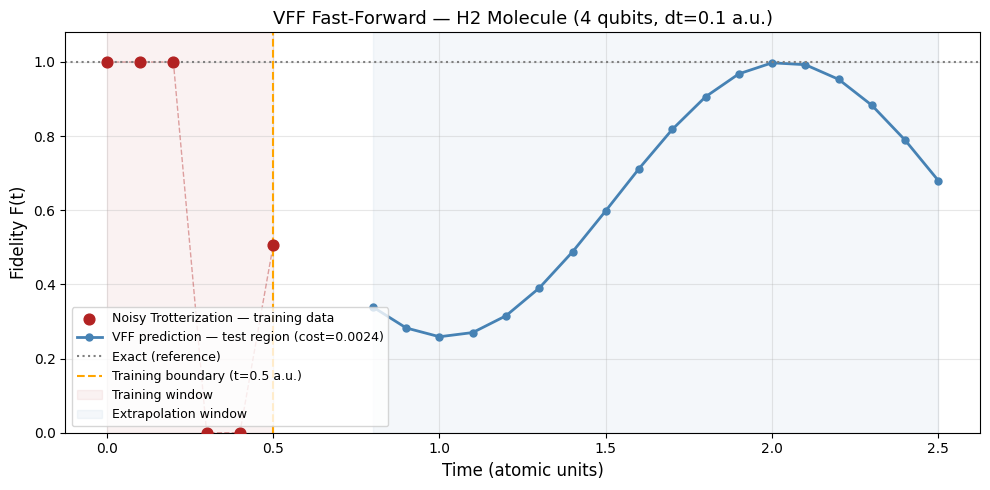

VFF extrapolates 5x beyond the training window
at mean fidelity 0.647 vs exact long-time states.


In [18]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.scatter(x_train, fid_train_vs_exact, color='firebrick', s=60, zorder=5,
           label='Noisy Trotterization — training data')
ax.plot(x_train, fid_train_vs_exact, '--', color='firebrick', alpha=0.4, linewidth=1)

ax.plot(x_test, fid_vff_vs_exact, '-o', color='steelblue', linewidth=2.0, markersize=5,
        label=f'VFF prediction — test region (cost={history_mol[-1]:.4f})')

ax.axhline(1.0, color='gray', linestyle=':', linewidth=1.5, label='Exact (reference)')

ax.axvline(x_train[-1], color='orange', linestyle='--', linewidth=1.5,
           label=f'Training boundary (t={x_train[-1]:.1f} a.u.)')
ax.axvspan(x_train[0], x_train[-1], alpha=0.06, color='firebrick', label='Training window')
ax.axvspan(x_test[0],  x_test[-1],  alpha=0.06, color='steelblue', label='Extrapolation window')

ax.set_xlabel('Time (atomic units)', fontsize=12)
ax.set_ylabel('Fidelity F(t)', fontsize=12)
ax.set_title(
    f'VFF Fast-Forward — {MOLECULE} Molecule ({N_MOL} qubits, dt={DT_MOL} a.u.)',
    fontsize=13)
ax.set_ylim(0, 1.08)
ax.legend(fontsize=9, loc='lower left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"VFF extrapolates {TEST_END / TRAIN_END:.0f}x beyond the training window")
print(f"at mean fidelity {np.mean(fid_vff_vs_exact):.3f} vs exact long-time states.")


## 6. Summary

| Part | Model | Key result |
|------|-------|-----------|
| **A — Algorithm** | TFIM, 4 qubits | VFF (ideal, fixed depth) outperforms noisy Trotterization from N=1 onwards |
| **B — Application** | H₂ molecule, 4 qubits | VFF trained on 5 noisy steps accurately predicts states 5× beyond the training horizon |

**Why VFF works:**
- The variational circuit $V(\alpha, \Delta t) = W^\dagger D(\gamma, \Delta t) W$ approximates $e^{-iH\Delta t}$
- The diagonal structure lets you fast-forward: $V(N) = W^\dagger D(N\gamma, \Delta t) W$ at **fixed circuit depth**
- On noisy hardware, fixed depth = fixed noise floor, while Trotterization accumulates errors with $N$

**References:**

[1] Cîrstoiu C, Holmes Z, Iosue J, Cincio L, Coles PJ, Sornborger A. *Variational fast forwarding for quantum simulation beyond the coherence time*. npj Quantum Inf. 2020;6:82. [arXiv:1910.04292](https://arxiv.org/abs/1910.04292)

[2] Filip M-A, Muñoz Ramo D, Fitzpatrick N. *Variational Phase Estimation with Variational Fast Forwarding*. Quantum. 2024;8:1278. [arXiv:2211.16097](https://arxiv.org/abs/2211.16097)

[3] Nandha V R et al. *H-molecule evolution dataset for VFF benchmarking*. `qiskit-machine-learning` PR #916 (2025).
